<a href="https://colab.research.google.com/github/elias8080007/OIBSIP/blob/main/DataAnalytics-L1-CustomerSegmentation/Elias_Ibrahim_Elias_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation Analysis Using RFM and K-Means

**Intern:** Elias Ibrahim Elias  
**Track:** Data Analytics  
**Organization:** Oasis Infobyte  
**Task:** Level 1 — Task 2  

## Project Objective

The objective of this project is to segment an online retail company's customers into distinct groups based on purchasing behaviour. Recency, Frequency, and Monetary value will be calculated for each customer and used with K-Means clustering to support targeted marketing strategies.

## Dataset

The Online Retail dataset was obtained from the UCI Machine Learning Repository. It contains transactional records from a UK-based online retailer between December 2010 and December 2011.

**Source:** https://archive.ics.uci.edu/dataset/352/online+retail

## 1. Environment Setup and Dataset Loading

The required Python libraries are imported and the Online Retail dataset is downloaded directly from the UCI Machine Learning Repository. Loading the data programmatically makes the notebook reproducible without requiring manual file uploads.

In [1]:
# File and utility libraries
import os
import warnings
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

# Data analysis and visualisation
import numpy as np #for data preparation and calculations
import pandas as pd #for data preparation and calculations
import matplotlib.pyplot as plt
import seaborn as sns

# Machine-learning tools
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans # creates customer segments
from sklearn.metrics import silhouette_score

# Notebook configuration
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", palette="viridis")

# Project directories
DATA_DIRECTORY = Path("/content/data")
OUTPUT_DIRECTORY = Path("/content/outputs")

DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Environment setup completed.")

Environment setup completed.


In [2]:
# Official UCI Online Retail dataset
dataset_url = (
    "https://archive.ics.uci.edu/static/public/352/"
    "online%2Bretail.zip"
)

zip_path = DATA_DIRECTORY / "online_retail.zip"

# Download only when the ZIP file is not already available
if not zip_path.exists():
    urlretrieve(dataset_url, zip_path)
    print("Dataset downloaded successfully.")
else:
    print("Dataset ZIP already exists.")

# Extract the dataset
with ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall(DATA_DIRECTORY)

# Find the extracted Excel file
excel_files = list(DATA_DIRECTORY.rglob("*.xlsx"))

if not excel_files:
    raise FileNotFoundError("The Online Retail Excel file was not found.")

dataset_path = excel_files[0]

# Load the complete dataset
df = pd.read_excel(dataset_path, engine="openpyxl")

print(f"Dataset loaded from: {dataset_path.name}")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset ZIP already exists.
Dataset loaded from: Online Retail.xlsx
Dataset shape: 541,909 rows × 8 columns


## 2. Initial Data Inspection

The dataset structure is examined before cleaning. This inspection identifies column types, missing values, duplicate records, and other potential data-quality issues.

In [3]:
# Preview the first five transactions
display(df.head())

# Compact structural and missing-value report
inspection_report = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Non_Null_Count": df.notna().sum(),
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2),
    "Unique_Values": df.nunique()
})

display(inspection_report)

print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print("\nColumn names:")
print(df.columns.tolist())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


,Data_Type,Non_Null_Count,Missing_Count,Missing_Percentage,Unique_Values
InvoiceNo,object,541909,0,0.00,25900
StockCode,object,541909,0,0.00,4070
Description,object,540455,1454,0.27,4223
Quantity,int64,541909,0,0.00,722
InvoiceDate,datetime64[ns],541909,0,0.00,23260
UnitPrice,float64,541909,0,0.00,1630
CustomerID,float64,406829,135080,24.93,4372
Country,object,541909,0,0.00,38


Number of rows: 541,909
Number of columns: 8
Duplicate rows: 5,268

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


### Initial Inspection Findings

The dataset contains **541,909 transaction records and 8 columns**. CustomerID has **135,080 missing values (24.93%)**, while Description has **1,454 missing values (0.27%)**. In addition, **5,268 duplicate rows** were detected.

Transactions without a CustomerID cannot be assigned reliably to a customer and will therefore be excluded from the segmentation analysis. Duplicate records, cancelled orders, invalid quantities, and non-positive prices will also be removed to prevent biased customer metrics.

## 3. Data Cleaning and Preparation

The dataset is cleaned before calculating customer behaviour. Duplicate records and transactions without customer identifiers are removed. Cancelled orders, invalid quantities, invalid prices, and invalid dates are excluded because they do not represent completed customer purchases.

Missing product descriptions are labelled as "Unknown Product" because the description is not required for calculating RFM features.

In [4]:
# Create a separate cleaned copy
df_clean = df.copy()

cleaning_log = []


def remove_invalid_rows(data, invalid_condition, step_name):
    """Remove rows matching a condition and record the result."""
    rows_removed = int(invalid_condition.sum())
    cleaned_data = data.loc[~invalid_condition].copy()

    cleaning_log.append({
        "Cleaning_Step": step_name,
        "Rows_Removed": rows_removed,
        "Rows_Remaining": len(cleaned_data)
    })

    return cleaned_data


# 1. Remove exact duplicate records
df_clean = remove_invalid_rows(
    df_clean,
    df_clean.duplicated(),
    "Remove duplicate rows"
)

# 2. Remove transactions without CustomerID
df_clean = remove_invalid_rows(
    df_clean,
    df_clean["CustomerID"].isna(),
    "Remove missing CustomerID"
)

# 3. Standardize identifier and text columns
df_clean["CustomerID"] = (
    df_clean["CustomerID"]
    .astype("int64")
    .astype(str)
)

df_clean["InvoiceNo"] = (
    df_clean["InvoiceNo"]
    .astype(str)
    .str.strip()
)

df_clean["StockCode"] = (
    df_clean["StockCode"]
    .astype(str)
    .str.strip()
)

df_clean["Country"] = (
    df_clean["Country"]
    .astype(str)
    .str.strip()
)

# Product description is not required for RFM calculations
missing_descriptions_filled = int(df_clean["Description"].isna().sum())

df_clean["Description"] = (
    df_clean["Description"]
    .fillna("Unknown Product")
    .astype(str)
    .str.strip()
)

# 4. Convert and validate transaction dates
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"],
    errors="coerce"
)

df_clean = remove_invalid_rows(
    df_clean,
    df_clean["InvoiceDate"].isna(),
    "Remove invalid transaction dates"
)

# 5. Remove cancelled invoices
df_clean = remove_invalid_rows(
    df_clean,
    df_clean["InvoiceNo"].str.upper().str.startswith("C"),
    "Remove cancelled invoices"
)

# 6. Keep only positive purchased quantities
df_clean = remove_invalid_rows(
    df_clean,
    df_clean["Quantity"] <= 0,
    "Remove non-positive quantities"
)

# 7. Keep only positive unit prices
df_clean = remove_invalid_rows(
    df_clean,
    df_clean["UnitPrice"] <= 0,
    "Remove non-positive unit prices"
)

# 8. Calculate revenue for each transaction line
df_clean["TotalPrice"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

# Display the cleaning process
cleaning_report = pd.DataFrame(cleaning_log)
display(cleaning_report)

print(
    f"Missing descriptions labelled as Unknown Product: "
    f"{missing_descriptions_filled:,}"
)

,Cleaning_Step,Rows_Removed,Rows_Remaining
0,Remove duplicate rows,5268,536641
1,Remove missing CustomerID,135037,401604
2,Remove invalid transaction dates,0,401604
3,Remove cancelled invoices,8872,392732
4,Remove non-positive quantities,0,392732
5,Remove non-positive unit prices,40,392692


Missing descriptions labelled as Unknown Product: 0


In [5]:
cleaning_validation = pd.Series({
    "Original rows": len(df),
    "Cleaned rows": len(df_clean),
    "Total rows removed": len(df) - len(df_clean),
    "Remaining missing values": int(df_clean.isna().sum().sum()),
    "Remaining duplicate rows": int(df_clean.duplicated().sum()),
    "Non-positive quantities": int((df_clean["Quantity"] <= 0).sum()),
    "Non-positive unit prices": int((df_clean["UnitPrice"] <= 0).sum()),
    "Cancelled invoices": int(
        df_clean["InvoiceNo"].str.upper().str.startswith("C").sum()
    ),
    "Unique customers": df_clean["CustomerID"].nunique(),
    "Unique invoices": df_clean["InvoiceNo"].nunique(),
    "First transaction": df_clean["InvoiceDate"].min(),
    "Last transaction": df_clean["InvoiceDate"].max()
}, name="Result").to_frame()

display(cleaning_validation)

print(f"Final dataset shape: {df_clean.shape}")
print(f"Total recorded sales: £{df_clean['TotalPrice'].sum():,.2f}")

,Result
Original rows,541909
Cleaned rows,392692
Total rows removed,149217
Remaining missing values,0
Remaining duplicate rows,0
Non-positive quantities,0
Non-positive unit prices,0
Cancelled invoices,0
Unique customers,4338
Unique invoices,18532


Final dataset shape: (392692, 9)
Total recorded sales: £8,887,208.89


### Cleaning Results

The cleaning process reduced the dataset from **541,909 to 392,692 valid transaction rows**, removing **149,217 records (27.54%)**. Most removals resulted from missing customer identifiers, followed by duplicate records and cancelled invoices.

The cleaned dataset contains **4,338 identifiable customers**, **18,532 completed invoices**, and approximately **£8.89 million in recorded sales**. No missing values, duplicate records, cancelled invoices, non-positive quantities, or invalid prices remain.

## 4. Customer Metrics and RFM Feature Engineering

Customer behaviour is summarized at the customer level using purchase history. The analysis calculates average purchase value, purchase frequency, and observed customer lifetime value.

Three behavioural features are then selected for clustering:

- **Recency:** Number of days since the customer's latest purchase.
- **Frequency:** Number of distinct completed invoices.
- **Monetary:** Total amount spent by the customer.

Because the dataset covers approximately one year, Customer Lifetime Value is treated as an observed historical value rather than a prediction of future lifetime spending.

In [6]:
# Use one day after the final transaction as the analysis date
analysis_date = (
    df_clean["InvoiceDate"].max().normalize()
    + pd.Timedelta(days=1)
)

# Aggregate transaction history at the customer level
customer_metrics = (
    df_clean.groupby("CustomerID", as_index=False)
    .agg(
        Last_Purchase_Date=("InvoiceDate", "max"),
        Purchase_Frequency=("InvoiceNo", "nunique"),
        Total_Spend=("TotalPrice", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
)

# Calculate customer-level business metrics
customer_metrics["Recency"] = (
    analysis_date - customer_metrics["Last_Purchase_Date"]
).dt.days

customer_metrics["Average_Purchase_Value"] = (
    customer_metrics["Total_Spend"]
    / customer_metrics["Purchase_Frequency"]
)

# Observed CLV during the available dataset period
customer_metrics["Observed_CLV"] = (
    customer_metrics["Average_Purchase_Value"]
    * customer_metrics["Purchase_Frequency"]
)

# Create the RFM table used for clustering
rfm = (
    customer_metrics[
        [
            "CustomerID",
            "Recency",
            "Purchase_Frequency",
            "Observed_CLV"
        ]
    ]
    .rename(columns={
        "Purchase_Frequency": "Frequency",
        "Observed_CLV": "Monetary"
    })
    .copy()
)

print(f"Analysis date: {analysis_date.date()}")
print(f"Customers in RFM table: {len(rfm):,}")

display(rfm.head(10))

Analysis date: 2011-12-10
Customers in RFM table: 4,338


,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,"77,183.60"
1,12347,2,7,"4,310.00"
2,12348,75,4,"1,797.24"
3,12349,18,1,"1,757.55"
4,12350,310,1,334.40
5,12352,36,8,"2,506.04"
6,12353,204,1,89.00
7,12354,232,1,"1,079.40"
8,12355,214,1,459.40
9,12356,22,3,"2,811.43"


In [7]:
# Overall customer KPIs
overall_kpis = pd.Series({
    "Total Customers": customer_metrics["CustomerID"].nunique(),
    "Total Completed Orders": df_clean["InvoiceNo"].nunique(),
    "Total Revenue": df_clean["TotalPrice"].sum(),
    "Overall Average Order Value": (
        df_clean["TotalPrice"].sum()
        / df_clean["InvoiceNo"].nunique()
    ),
    "Average Purchase Frequency": (
        customer_metrics["Purchase_Frequency"].mean()
    ),
    "Average Observed CLV": (
        customer_metrics["Observed_CLV"].mean()
    ),
    "Median Observed CLV": (
        customer_metrics["Observed_CLV"].median()
    )
}, name="Value").to_frame()

display(overall_kpis)

# Descriptive statistics for the required customer metrics
required_metrics = [
    "Average_Purchase_Value",
    "Purchase_Frequency",
    "Observed_CLV"
]

customer_statistics = (
    customer_metrics[required_metrics]
    .describe()
    .T
    .rename(columns={
        "count": "Count",
        "mean": "Mean",
        "std": "Standard_Deviation",
        "min": "Minimum",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Maximum"
    })
    [
        [
            "Count",
            "Mean",
            "Median",
            "Standard_Deviation",
            "Minimum",
            "Q1",
            "Q3",
            "Maximum"
        ]
    ]
    .round(2)
)

display(customer_statistics)

,Value
Total Customers,"4,338.00"
Total Completed Orders,"18,532.00"
Total Revenue,"8,887,208.89"
Overall Average Order Value,479.56
Average Purchase Frequency,4.27
Average Observed CLV,"2,048.69"
Median Observed CLV,668.57


,Count,Mean,Median,Standard_Deviation,Minimum,Q1,Q3,Maximum
Average_Purchase_Value,"4,338.00",417.65,291.94,"1,796.51",3.45,177.87,428.28,"84,236.25"
Purchase_Frequency,"4,338.00",4.27,2.00,7.70,1.00,1.00,5.00,209.00
Observed_CLV,"4,338.00","2,048.69",668.57,"8,985.23",3.75,306.48,"1,660.60","280,206.02"


### Customer Behaviour Findings

The average customer completed **4.27 purchases**, although the median customer completed only **2 purchases**, indicating that a smaller group of highly active customers increases the average.

Average observed customer value was **£2,048.69**, compared with a median of only **£668.57**. The maximum observed value reached **£280,206.02**, demonstrating substantial differences between ordinary customers and high-value customers. These results indicate strongly right-skewed behavioural features that should be transformed before K-Means clustering.

## 5. RFM Distribution and Skewness Analysis

RFM distributions are examined before clustering. K-Means uses distance calculations and can be strongly influenced by extreme values, particularly when Monetary and Frequency contain highly active wholesale customers.

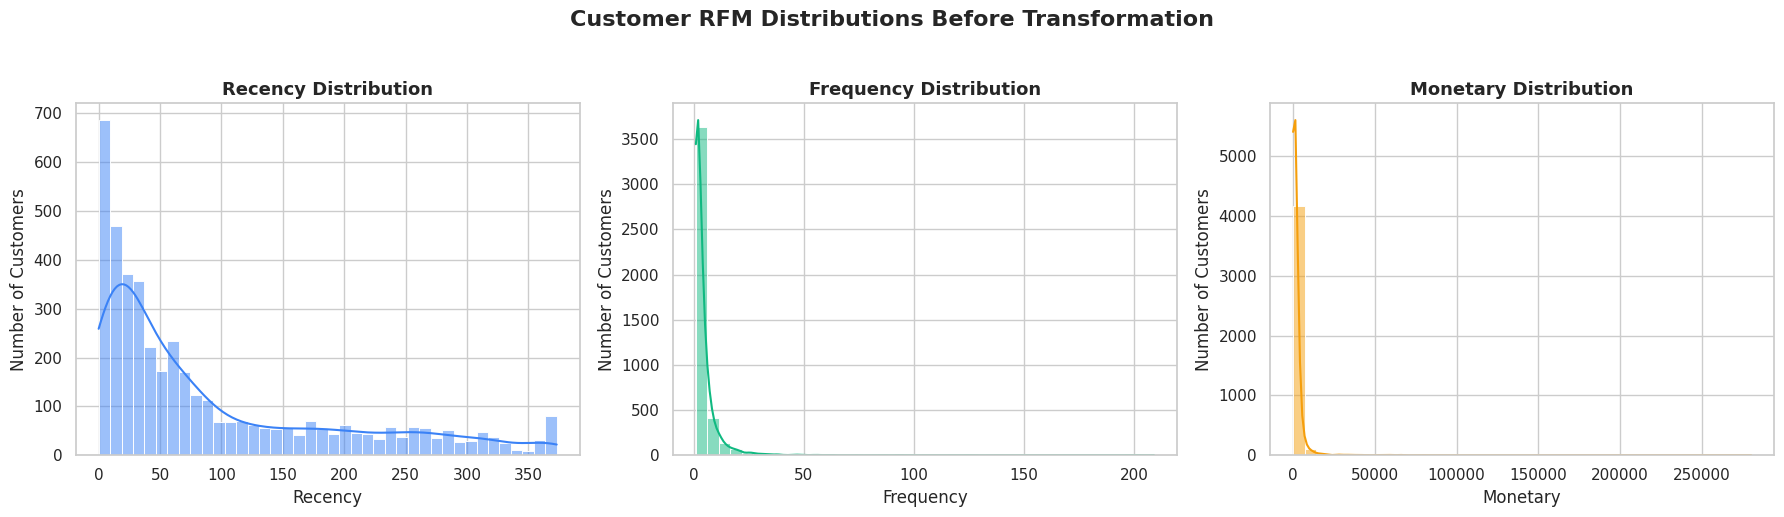

Original feature skewness:


,Skewness
Recency,1.25
Frequency,12.07
Monetary,19.34


In [8]:
rfm_features = ["Recency", "Frequency", "Monetary"]

# Calculate original skewness
original_skewness = rfm[rfm_features].skew()

# Plot the three original RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

chart_colors = ["#3B82F6", "#10B981", "#F59E0B"]

for axis, feature, color in zip(
    axes,
    rfm_features,
    chart_colors
):
    sns.histplot(
        data=rfm,
        x=feature,
        bins=40,
        kde=True,
        color=color,
        ax=axis
    )

    axis.set_title(
        f"{feature} Distribution",
        fontsize=13,
        fontweight="bold"
    )
    axis.set_xlabel(feature)
    axis.set_ylabel("Number of Customers")

plt.suptitle(
    "Customer RFM Distributions Before Transformation",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIRECTORY / "rfm_distributions_before_transformation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Original feature skewness:")
display(original_skewness.to_frame("Skewness").round(2))

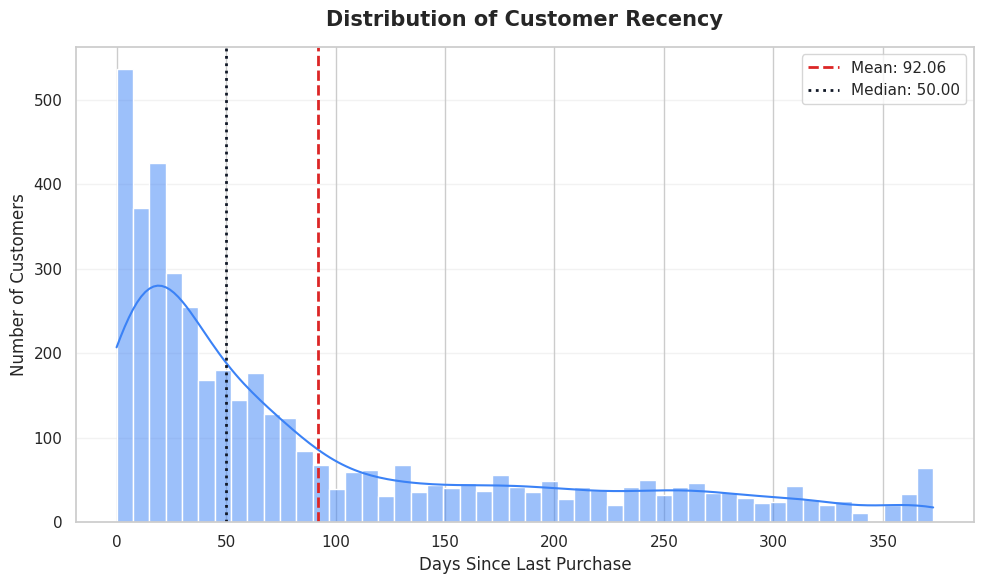

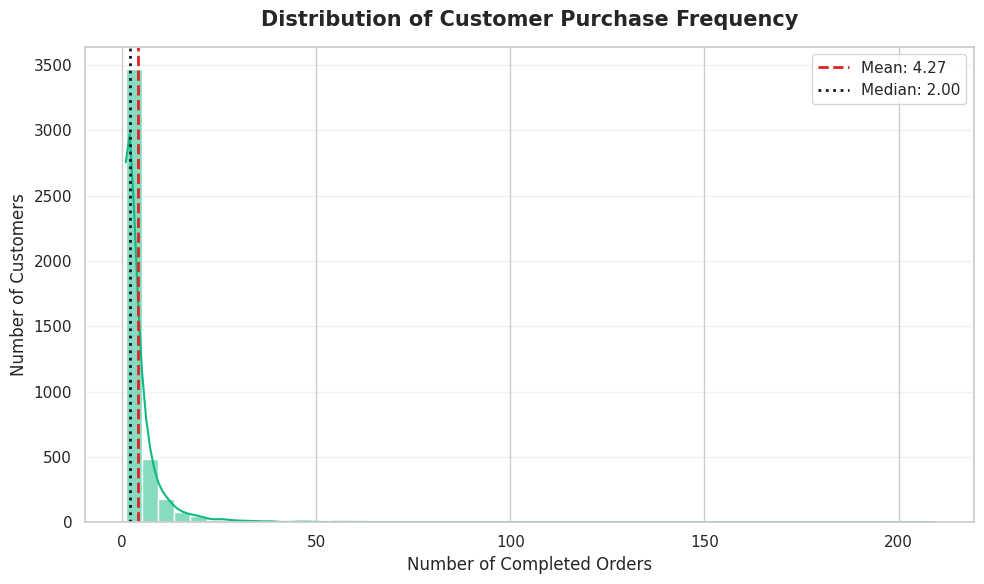

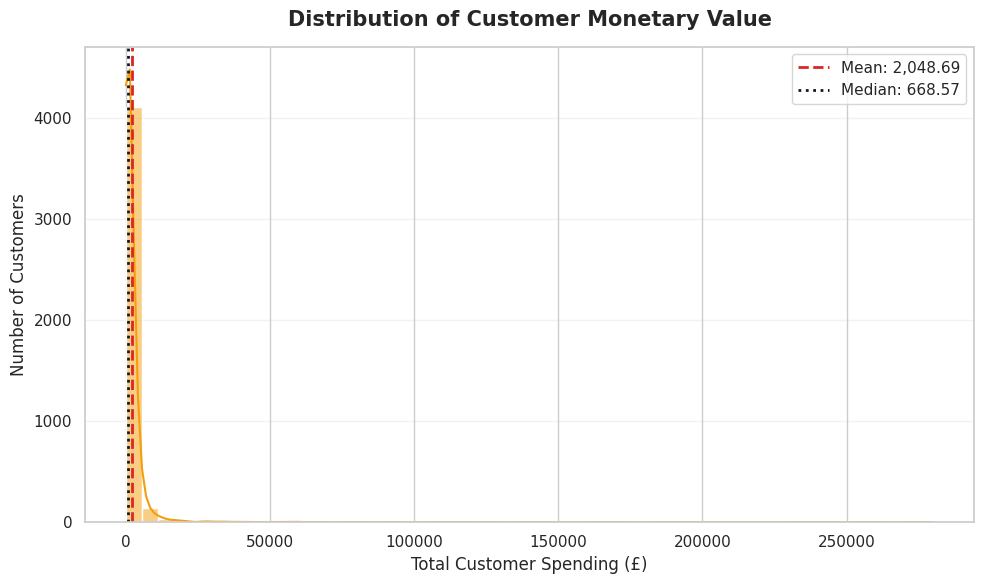

Original feature skewness:


,Skewness
Recency,1.25
Frequency,12.07
Monetary,19.34


In [9]:
# Settings for three separate RFM distribution charts
distribution_settings = {
    "Recency": {
        "color": "#3B82F6",
        "title": "Distribution of Customer Recency",
        "xlabel": "Days Since Last Purchase",
        "filename": "recency_distribution.png"
    },
    "Frequency": {
        "color": "#10B981",
        "title": "Distribution of Customer Purchase Frequency",
        "xlabel": "Number of Completed Orders",
        "filename": "frequency_distribution.png"
    },
    "Monetary": {
        "color": "#F59E0B",
        "title": "Distribution of Customer Monetary Value",
        "xlabel": "Total Customer Spending (£)",
        "filename": "monetary_distribution.png"
    }
}

for feature, settings in distribution_settings.items():

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=rfm,
        x=feature,
        bins=50,
        kde=True,
        color=settings["color"]
    )

    # Add mean and median reference lines
    plt.axvline(
        rfm[feature].mean(),
        color="#DC2626",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {rfm[feature].mean():,.2f}"
    )

    plt.axvline(
        rfm[feature].median(),
        color="#111827",
        linestyle=":",
        linewidth=2,
        label=f"Median: {rfm[feature].median():,.2f}"
    )

    plt.title(
        settings["title"],
        fontsize=15,
        fontweight="bold",
        pad=15
    )
    plt.xlabel(settings["xlabel"])
    plt.ylabel("Number of Customers")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIRECTORY / settings["filename"],
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# Display skewness once after the three charts
print("Original feature skewness:")

display(
    original_skewness
    .to_frame("Skewness")
    .round(2)
)

### Observation

All three RFM features are positively skewed. Recency has a skewness of **1.25**, while Frequency and Monetary have substantially stronger skewness values of **12.07** and **19.34**, respectively.

The large differences between the mean and median lines confirm that a relatively small number of highly active and high-spending customers influence the distributions. A logarithmic transformation is therefore appropriate because it reduces extreme skewness while retaining potentially valuable wholesale and VIP customers.

## 7. Selecting the Optimal Number of Clusters

The Elbow Method measures how compact the clusters become as the number of clusters increases. The optimal value appears near the point where adding more clusters produces only a small improvement in inertia.

The Silhouette Score measures both cluster cohesion and separation. Values closer to 1 indicate more clearly separated clusters. Both methods are considered before choosing the final number of customer segments.

In [10]:
# Select the three RFM clustering features
rfm_features = ["Recency", "Frequency", "Monetary"]

# Reduce positive skewness while retaining high-value customers
rfm_log = np.log1p(rfm[rfm_features])

# Standardize features for K-Means
scaler = StandardScaler()

rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_log),
    columns=rfm_features,
    index=rfm.index
)

# Verify the result
scaled_summary = (
    rfm_scaled
    .describe()
    .T[["mean", "std", "min", "max"]]
    .rename(columns={
        "mean": "Mean",
        "std": "Standard_Deviation",
        "min": "Minimum",
        "max": "Maximum"
    })
    .round(2)
)

display(scaled_summary)

print(f"Scaled RFM shape: {rfm_scaled.shape}")

,Mean,Standard_Deviation,Minimum,Maximum
Recency,-0.00,1.00,-2.75,1.53
Frequency,-0.00,1.00,-0.96,5.86
Monetary,-0.00,1.00,-4.00,4.73


Scaled RFM shape: (4338, 3)


### Standardization Results

The standardized Recency, Frequency, and Monetary features all have means approximately equal to **0** and standard deviations equal to **1**, confirming that the transformation was successful.

The features now use comparable scales, preventing Monetary value or Frequency from dominating the K-Means distance calculations. All **4,338 customers** were retained, including potentially valuable wholesale and VIP customers.

In [11]:
# Evaluate possible numbers of clusters
cluster_results = []

for k in range(1, 11):

    candidate_model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=42
    )

    candidate_labels = candidate_model.fit_predict(rfm_scaled)

    result = {
        "K": k,
        "Inertia": candidate_model.inertia_,
        "Silhouette_Score": np.nan
    }

    # Silhouette Score cannot be calculated for one cluster
    if k >= 2:
        result["Silhouette_Score"] = silhouette_score(
            rfm_scaled,
            candidate_labels
        )

    cluster_results.append(result)

cluster_evaluation = pd.DataFrame(cluster_results)

display(cluster_evaluation.round(4))

,K,Inertia,Silhouette_Score
0,1,"13,014.00",NaN
1,2,"6,488.01",0.43
2,3,"4,879.13",0.34
3,4,"3,962.70",0.34
4,5,"3,331.73",0.32
5,6,"2,875.40",0.31
6,7,"2,573.18",0.31
7,8,"2,359.57",0.30
8,9,"2,178.47",0.28
9,10,"2,021.27",0.28


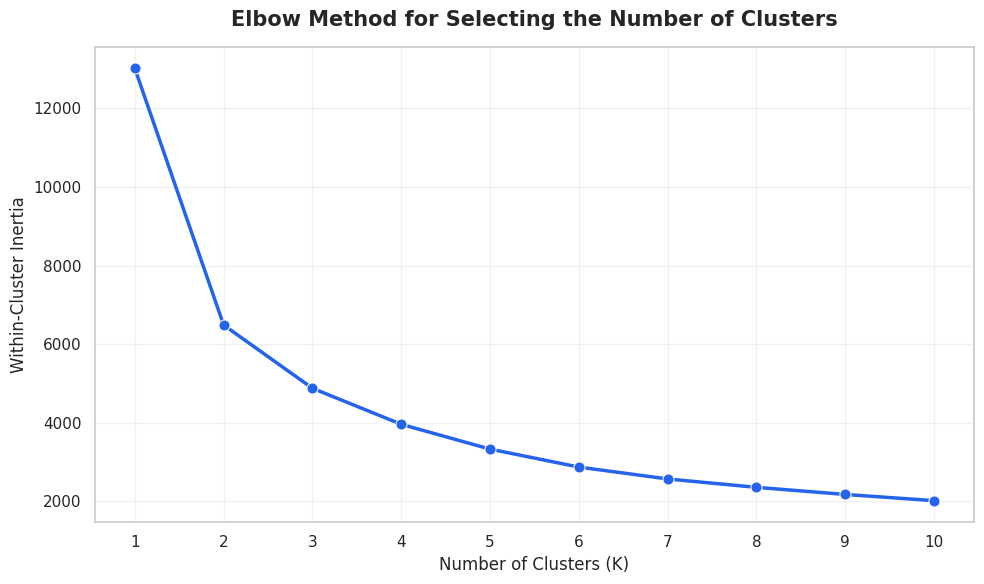

In [12]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=cluster_evaluation,
    x="K",
    y="Inertia",
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#2563EB"
)

plt.title(
    "Elbow Method for Selecting the Number of Clusters",
    fontsize=15,
    fontweight="bold",
    pad=15
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Inertia")
plt.xticks(range(1, 11))
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIRECTORY / "elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

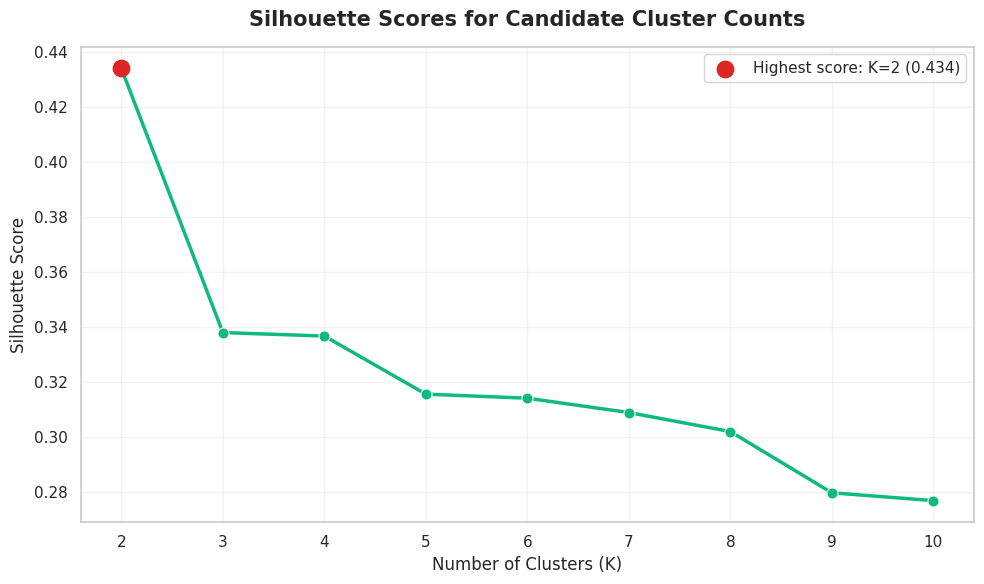

In [13]:
silhouette_results = cluster_evaluation.dropna(
    subset=["Silhouette_Score"]
).copy()

best_silhouette_row = silhouette_results.loc[
    silhouette_results["Silhouette_Score"].idxmax()
]

best_silhouette_k = int(best_silhouette_row["K"])
best_silhouette_value = best_silhouette_row["Silhouette_Score"]

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=silhouette_results,
    x="K",
    y="Silhouette_Score",
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#10B981"
)

plt.scatter(
    best_silhouette_k,
    best_silhouette_value,
    color="#DC2626",
    s=140,
    zorder=5,
    label=(
        f"Highest score: K={best_silhouette_k} "
        f"({best_silhouette_value:.3f})"
    )
)

plt.title(
    "Silhouette Scores for Candidate Cluster Counts",
    fontsize=15,
    fontweight="bold",
    pad=15
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIRECTORY / "silhouette_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Cluster Selection

The highest Silhouette Score was **0.434 for K=2**, indicating that two clusters provide the strongest statistical separation. However, two groups would provide only a broad division of the customer base and would limit the usefulness of targeted marketing strategies.

The Elbow curve continues to decrease meaningfully until approximately **K=4**, after which improvements become more gradual. K=4 also achieves a Silhouette Score of approximately **0.337**, nearly identical to K=3, while providing greater customer-segment detail.

Therefore, **four clusters were selected** as a balance between statistical quality, Elbow Method results, and business interpretability.

## 8. Final K-Means Customer Segmentation

The final K-Means model is trained using four clusters. The model uses the logarithmically transformed and standardized RFM features to ensure balanced distance calculations.

In [14]:
# Selected number of clusters
SELECTED_K = 4

# Train the final K-Means model
final_kmeans = KMeans(
    n_clusters=SELECTED_K,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

# Assign each customer to a cluster
rfm["Cluster"] = final_kmeans.fit_predict(rfm_scaled)

# Evaluate the final model
final_silhouette_score = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

# Calculate cluster sizes
cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Customer_Count")
)

cluster_counts["Customer_Percentage"] = (
    cluster_counts["Customer_Count"]
    / len(rfm)
    * 100
).round(2)

display(cluster_counts)

print(f"Selected number of clusters: {SELECTED_K}")
print(f"Final Silhouette Score: {final_silhouette_score:.3f}")
print(f"Final model inertia: {final_kmeans.inertia_:,.2f}")

,Cluster,Customer_Count,Customer_Percentage
0,0,699,16.11
1,1,1635,37.69
2,2,826,19.04
3,3,1178,27.16


Selected number of clusters: 4
Final Silhouette Score: 0.337
Final model inertia: 3,962.70


### Final Model Results

The final K-Means model divided the **4,338 customers** into four substantial groups. The largest cluster contains **1,635 customers (37.69%)**, while the smallest contains **699 customers (16.11%)**.

The final Silhouette Score is **0.337**, indicating moderate cluster separation. No cluster is extremely small, so every resulting segment represents a meaningful portion of the customer base that can be considered in marketing decisions.

## 9. Customer Cluster Profiling

Each cluster is profiled using its original, unscaled Recency, Frequency, and Monetary values. Mean and median values are examined alongside customer percentage and revenue contribution to identify the purchasing behaviour represented by each cluster.

For Recency, lower values indicate more recent activity. For Frequency and Monetary value, higher values indicate stronger customer engagement and spending.

In [15]:
# Profile clusters using original RFM values
cluster_profile = (
    rfm.groupby("Cluster", as_index=False)
    .agg(
        Customer_Count=("CustomerID", "count"),
        Average_Recency=("Recency", "mean"),
        Median_Recency=("Recency", "median"),
        Average_Frequency=("Frequency", "mean"),
        Median_Frequency=("Frequency", "median"),
        Average_Monetary=("Monetary", "mean"),
        Median_Monetary=("Monetary", "median"),
        Total_Cluster_Revenue=("Monetary", "sum")
    )
)

# Calculate customer and revenue contributions
cluster_profile["Customer_Percentage"] = (
    cluster_profile["Customer_Count"]
    / len(rfm)
    * 100
)

cluster_profile["Revenue_Percentage"] = (
    cluster_profile["Total_Cluster_Revenue"]
    / rfm["Monetary"].sum()
    * 100
)

# Arrange columns clearly
cluster_profile = cluster_profile[
    [
        "Cluster",
        "Customer_Count",
        "Customer_Percentage",
        "Average_Recency",
        "Median_Recency",
        "Average_Frequency",
        "Median_Frequency",
        "Average_Monetary",
        "Median_Monetary",
        "Total_Cluster_Revenue",
        "Revenue_Percentage"
    ]
]

display(cluster_profile.round(2))

,Cluster,Customer_Count,Customer_Percentage,Average_Recency,Median_Recency,Average_Frequency,Median_Frequency,Average_Monetary,Median_Monetary,Total_Cluster_Revenue,Revenue_Percentage
0,0,699,16.11,11.37,8.00,13.88,10.00,"8,194.29","3,750.40","5,727,810.03",64.45
1,1,1635,37.69,180.27,173.00,1.32,1.00,344.24,296.64,"562,832.89",6.33
2,2,826,19.04,17.28,16.00,2.18,2.00,555.80,480.11,"459,089.32",5.17
3,3,1178,27.16,69.95,53.50,4.14,4.00,"1,814.50","1,351.82","2,137,476.65",24.05


### Cluster Interpretation

- **Cluster 0 — Champions:** These 699 customers purchase very recently and frequently, with an average monetary value of **£8,194.29**. Although they represent only **16.11%** of customers, they generate **64.45%** of total revenue.

- **Cluster 1 — Hibernating:** This is the largest segment, containing 1,635 customers. Their average recency is approximately **180 days**, with only **1.32 purchases** and **£344.24** in average spending. They contribute only **6.33%** of revenue.

- **Cluster 2 — Promising:** These 826 customers purchased recently, with an average recency of approximately **17 days**, but currently have low frequency and spending. They may develop into regular customers with suitable follow-up campaigns.

- **Cluster 3 — Regular Customers:** These 1,178 customers have moderate recency, an average of **4.14 purchases**, and average spending of **£1,814.50**. They generate **24.05%** of revenue and represent an important group for loyalty development.

In [16]:
# Assign meaningful names based on cluster profiles
cluster_name_mapping = {
    0: "Champions",
    1: "Hibernating",
    2: "Promising",
    3: "Regular Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_name_mapping)
cluster_profile["Segment"] = cluster_profile["Cluster"].map(
    cluster_name_mapping
)

# Display a concise named profile
named_cluster_profile = cluster_profile[
    [
        "Cluster",
        "Segment",
        "Customer_Count",
        "Customer_Percentage",
        "Average_Recency",
        "Average_Frequency",
        "Average_Monetary",
        "Revenue_Percentage"
    ]
].copy()

display(named_cluster_profile.round(2))

,Cluster,Segment,Customer_Count,Customer_Percentage,Average_Recency,Average_Frequency,Average_Monetary,Revenue_Percentage
0,0,Champions,699,16.11,11.37,13.88,"8,194.29",64.45
1,1,Hibernating,1635,37.69,180.27,1.32,344.24,6.33
2,2,Promising,826,19.04,17.28,2.18,555.80,5.17
3,3,Regular Customers,1178,27.16,69.95,4.14,"1,814.50",24.05


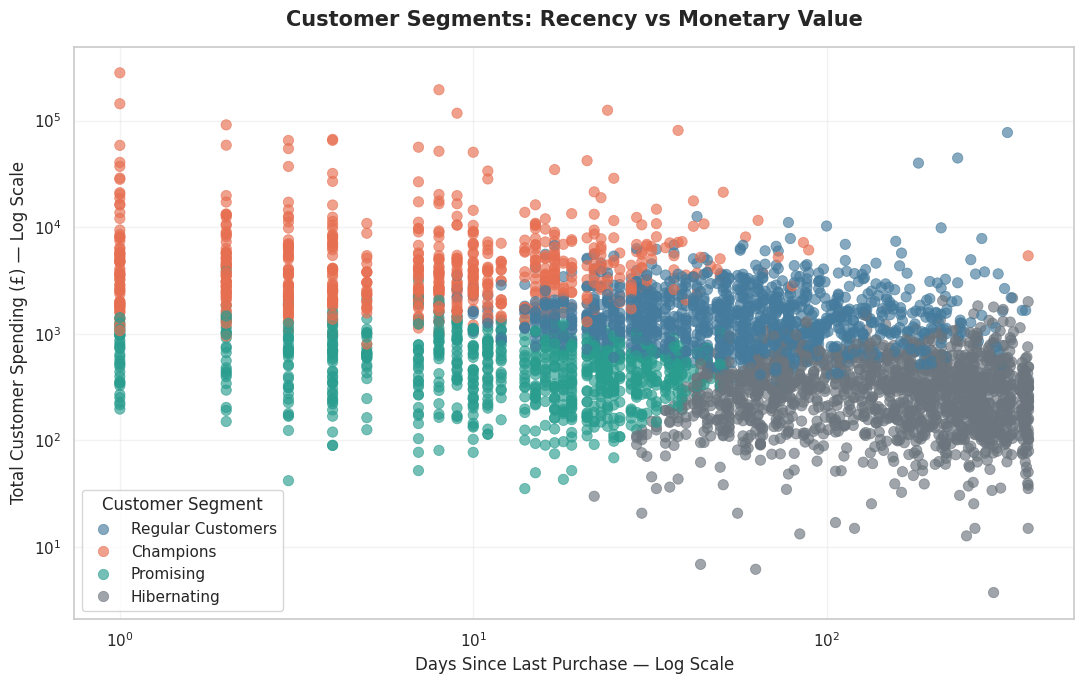

In [17]:
segment_palette = {
    "Champions": "#E76F51",
    "Hibernating": "#6C757D",
    "Promising": "#2A9D8F",
    "Regular Customers": "#457B9D"
}

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    palette=segment_palette,
    alpha=0.65,
    s=55,
    edgecolor=None
)

# Logarithmic axes improve visibility of highly skewed values
plt.xscale("log")
plt.yscale("log")

plt.title(
    "Customer Segments: Recency vs Monetary Value",
    fontsize=15,
    fontweight="bold",
    pad=15
)
plt.xlabel("Days Since Last Purchase — Log Scale")
plt.ylabel("Total Customer Spending (£) — Log Scale")
plt.legend(title="Customer Segment")
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIRECTORY / "clusters_recency_vs_monetary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Champions are concentrated toward the upper-left region, demonstrating recent activity and high spending. Hibernating customers are primarily located toward the lower-right, representing low spending and long periods of inactivity.

Promising customers purchased recently but currently have relatively low monetary values, while Regular Customers generally occupy the middle region. This confirms that Recency and Monetary value distinguish customers with substantially different engagement and financial value.

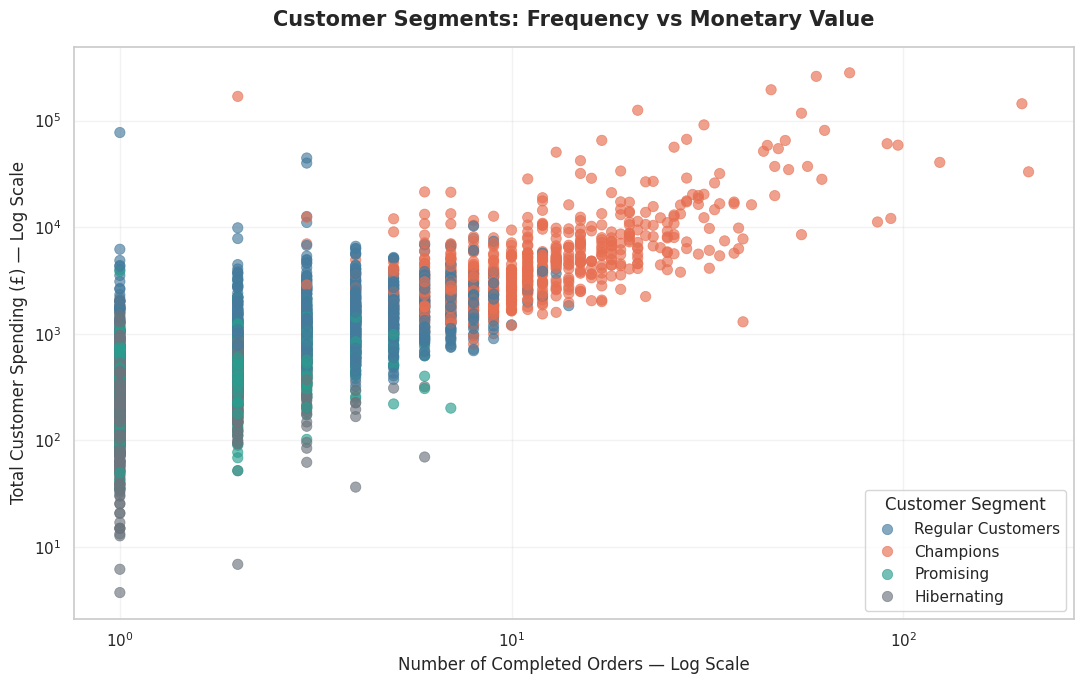

In [18]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    palette=segment_palette,
    alpha=0.65,
    s=55,
    edgecolor=None
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Customer Segments: Frequency vs Monetary Value",
    fontsize=15,
    fontweight="bold",
    pad=15
)
plt.xlabel("Number of Completed Orders — Log Scale")
plt.ylabel("Total Customer Spending (£) — Log Scale")
plt.legend(title="Customer Segment")
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIRECTORY / "clusters_frequency_vs_monetary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Customer spending generally increases with purchase frequency. Champions occupy the upper-right region because they purchase frequently and generate high monetary value, while Hibernating customers are concentrated around low frequency and low spending.

Regular Customers show moderate frequency and monetary value, while Promising customers generally remain at lower levels. Some points overlap because this two-dimensional chart displays only Frequency and Monetary, while the K-Means model also uses Recency as a third feature.

## 10. Customer Distribution Across Segments

The number and percentage of customers in each segment are compared to understand the relative size of the groups. Segment size should be interpreted alongside revenue contribution because a smaller segment may still generate substantial business value.

,Cluster,Segment,Customer_Count,Customer_Percentage
0,0,Champions,699,16.11
1,3,Regular Customers,1178,27.16
2,2,Promising,826,19.04
3,1,Hibernating,1635,37.69


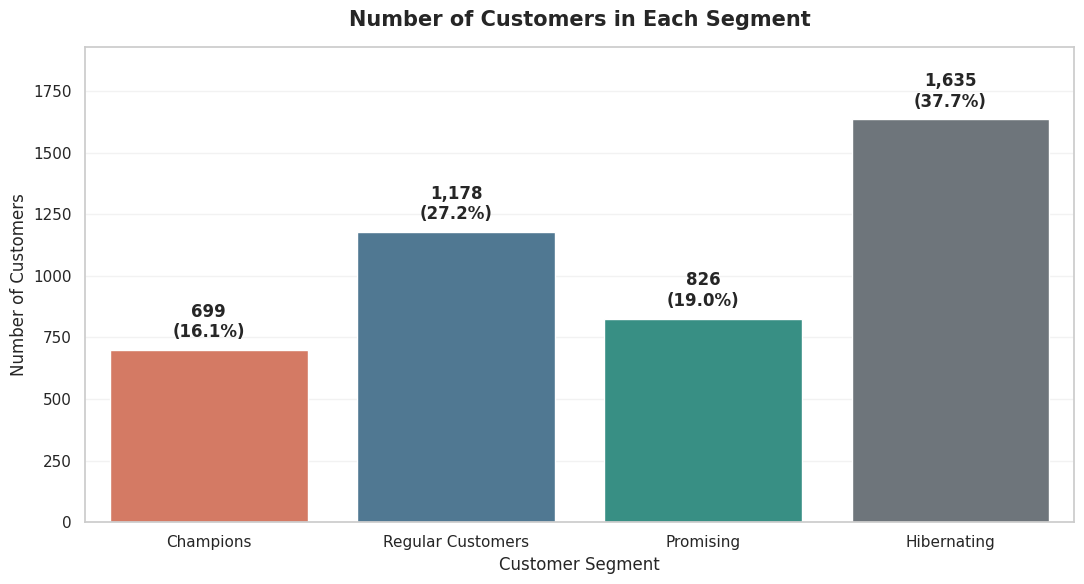

In [19]:
# Calculate the number of customers in each segment
segment_counts = (
    rfm.groupby(
        ["Cluster", "Segment"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "Customer_Count"})
)

segment_counts["Customer_Percentage"] = (
    segment_counts["Customer_Count"]
    / len(rfm)
    * 100
)

# Use a meaningful order in the chart
segment_order = [
    "Champions",
    "Regular Customers",
    "Promising",
    "Hibernating"
]

segment_counts["Segment"] = pd.Categorical(
    segment_counts["Segment"],
    categories=segment_order,
    ordered=True
)

segment_counts = (
    segment_counts
    .sort_values("Segment")
    .reset_index(drop=True)
)

display(segment_counts.round(2))

# Create the customer-count chart
plt.figure(figsize=(11, 6))

axis = sns.barplot(
    data=segment_counts,
    x="Segment",
    y="Customer_Count",
    hue="Segment",
    palette=segment_palette,
    legend=False
)

# Add customer count and percentage above every bar
for position, row in segment_counts.iterrows():

    axis.text(
        position,
        row["Customer_Count"] + 35,
        (
            f"{int(row['Customer_Count']):,}\n"
            f"({row['Customer_Percentage']:.1f}%)"
        ),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title(
    "Number of Customers in Each Segment",
    fontsize=15,
    fontweight="bold",
    pad=15
)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.ylim(
    0,
    segment_counts["Customer_Count"].max() * 1.18
)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIRECTORY / "customers_per_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Hibernating customers form the largest segment, with **1,635 customers (37.69%)**, followed by Regular Customers with **1,178 customers (27.16%)**. Promising customers represent **19.04%**, while Champions form the smallest segment at **16.11%**.

Segment size does not directly represent business value. Although Champions are the smallest group, they generate **64.45% of total revenue**. In comparison, Hibernating customers form the largest group but contribute only **6.33%**, demonstrating the importance of evaluating customer quality alongside customer quantity.

## 11. Segment-Specific Marketing Strategies

Each segment requires a different marketing approach based on its purchasing activity, frequency, and financial value.

### 1. Champions

**Customer profile**

- 699 customers representing 16.11% of the customer base
- Average recency: 11.37 days
- Average purchase frequency: 13.88 orders
- Average monetary value: £8,194.29
- Revenue contribution: 64.45%

**Recommended actions**

- Create an exclusive VIP loyalty tier.
- Provide early access to products and premium bundles.
- Introduce referral rewards.
- Avoid unnecessary discounts because these customers already purchase regularly.

**Performance indicators**

- Customer retention rate
- Repeat-purchase rate
- Referral conversions
- Revenue retained

---

### 2. Regular Customers

**Customer profile**

- 1,178 customers representing 27.16% of the customer base
- Average recency: 69.95 days
- Average purchase frequency: 4.14 orders
- Average monetary value: £1,814.50
- Revenue contribution: 24.05%

**Recommended actions**

- Provide personalized product recommendations.
- Introduce loyalty points and frequency-based rewards.
- Offer relevant product bundles and cross-selling opportunities.
- Encourage these customers to move toward the Champion segment.

**Performance indicators**

- Purchase frequency
- Average order value
- Loyalty-program participation
- Migration to the Champion segment

---

### 3. Promising Customers

**Customer profile**

- 826 customers representing 19.04% of the customer base
- Average recency: 17.28 days
- Average purchase frequency: 2.18 orders
- Average monetary value: £555.80
- Revenue contribution: 5.17%

**Recommended actions**

- Send structured onboarding messages.
- Provide a second- or third-purchase incentive.
- Recommend products related to previous purchases.
- Use limited-time offers to encourage another purchase.

**Performance indicators**

- Second-purchase conversion rate
- Time until the next purchase
- Repeat-order rate
- Growth in customer value

---

### 4. Hibernating Customers

**Customer profile**

- 1,635 customers representing 37.69% of the customer base
- Average recency: 180.27 days
- Average purchase frequency: 1.32 orders
- Average monetary value: £344.24
- Revenue contribution: 6.33%

**Recommended actions**

- Launch a controlled win-back campaign.
- Send personalized reactivation offers.
- Request feedback about why customers stopped purchasing.
- Reduce campaign spending on customers who repeatedly fail to respond.

**Performance indicators**

- Reactivation rate
- Win-back conversion rate
- Reactivation cost
- Revenue recovered

## 12. Conclusion

This analysis segmented **4,338 online retail customers** into four distinct behavioural groups using Recency, Frequency, and Monetary value. Logarithmic transformation and StandardScaler were applied before K-Means clustering to reduce skewness and ensure that all three features contributed fairly to the clustering process.

The analysis identified several important business findings:

1. **Protect the Champion segment.**  
   Champions represent only **16.11% of customers** but generate **64.45% of total revenue**. The company should prioritize retention, VIP benefits, exclusive access, and referral programs for this segment.

2. **Develop Regular Customers into Champions.**  
   Regular Customers contribute **24.05% of revenue** and already demonstrate established purchasing behaviour. Personalized recommendations, bundles, and loyalty rewards could increase their purchase frequency and monetary value.

3. **Encourage Promising customers to make additional purchases.**  
   Promising customers purchased recently but remain relatively low in frequency and spending. Structured onboarding and second-purchase incentives could help establish long-term purchasing habits.

4. **Use cost-controlled reactivation for Hibernating customers.**  
   Hibernating customers represent the largest group at **37.69%**, but contribute only **6.33% of revenue**. Win-back campaigns should be tested carefully and evaluated according to reactivation cost and conversion rate.

Overall, the segmentation demonstrates that customer count alone does not determine financial importance. Targeted marketing based on behavioural segments should improve resource allocation, customer retention, and campaign relevance.

### Limitations

The analysis uses approximately one year of historical transactions from a single UK online retailer. Monetary value therefore represents observed spending during the available period rather than predicted lifetime value. K-Means also requires the number of clusters to be selected in advance, and segment assignments may change when new customer behaviour becomes available. The model should be refreshed periodically using updated transaction data.